In [3]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt
df = pd.read_csv("../data/energy_dataset.csv")
df.head()

,surface_area,wall_area,roof_area,glazing_area,height,compactness,orientation,energy_class
0,274,378,272,19,4.702751,0.530007,4,1
1,339,359,175,18,4.972581,0.817926,1,0
2,314,297,140,17,3.809120,0.644334,2,0
3,332,448,170,17,5.141293,0.680344,4,0
4,313,342,260,28,4.652013,0.756585,2,1


In [4]:
X = df.drop(columns=["energy_class"])
y = df["energy_class"]

In [6]:
42

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape, "Test:", X_test.shape)


Train: (4000, 7) Test: (1000, 7)


In [8]:
def evaluate_model(model, X_test, y_test, title="Model"):
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average="macro")
    f1_weighted = f1_score(y_test, y_pred, average="weighted")

    print(f"=== {title} ===")
    print(f"Accuracy     : {acc:.4f}")
    print(f"F1-macro     : {f1_macro:.4f}")
    print(f"F1-weighted  : {f1_weighted:.4f}\n")

    print("Classification report (par classe):")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(values_format="d")
    plt.title(f"Matrice de confusion — {title}")
    plt.show()

    return {"accuracy": acc, "f1_macro": f1_macro, "f1_weighted": f1_weighted}


=== SVM Linéaire (C=1) ===
Accuracy     : 0.8690
F1-macro     : 0.7680
F1-weighted  : 0.8679

Classification report (par classe):
              precision    recall  f1-score   support

           0       0.94      0.91      0.93       569
           1       0.80      0.87      0.83       371
           2       0.63      0.48      0.55        60

    accuracy                           0.87      1000
   macro avg       0.79      0.75      0.77      1000
weighted avg       0.87      0.87      0.87      1000



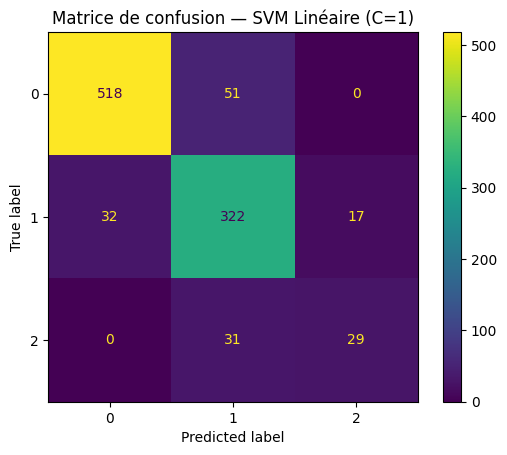

In [9]:
svm_linear = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("svc", SVC(kernel="linear", C=1.0))
])

svm_linear.fit(X_train, y_train)
res_linear = evaluate_model(svm_linear, X_test, y_test, title="SVM Linéaire (C=1)")


=== SVM RBF (C=1, gamma=scale) ===
Accuracy     : 0.8640
F1-macro     : 0.7347
F1-weighted  : 0.8588

Classification report (par classe):
              precision    recall  f1-score   support

           0       0.93      0.91      0.92       569
           1       0.78      0.88      0.83       371
           2       0.71      0.33      0.45        60

    accuracy                           0.86      1000
   macro avg       0.81      0.71      0.73      1000
weighted avg       0.86      0.86      0.86      1000



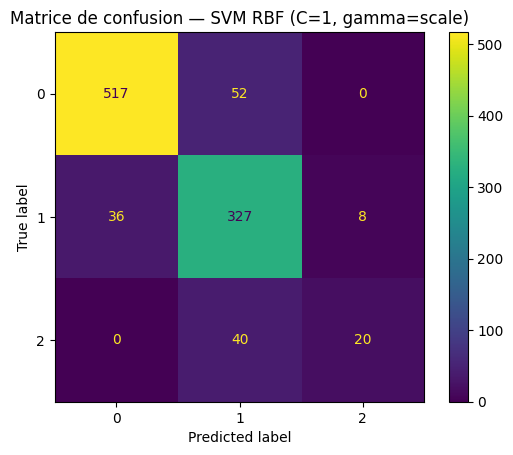

In [10]:
svm_rbf = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("svc", SVC(kernel="rbf", C=1.0, gamma="scale"))
])

svm_rbf.fit(X_train, y_train)
res_rbf = evaluate_model(svm_rbf, X_test, y_test, title="SVM RBF (C=1, gamma=scale)")


In [11]:
results_df = pd.DataFrame([
    {"model": "SVM Linear", **res_linear},
    {"model": "SVM RBF", **res_rbf},
]).sort_values("f1_macro", ascending=False)

results_df


,model,accuracy,f1_macro,f1_weighted
0,SVM Linear,0.869,0.767988,0.867915
1,SVM RBF,0.864,0.734654,0.858777


Meilleur C (linéaire): {'svc__C': 10}
Meilleur score CV (f1_macro): 0.7759802863274278
=== Best SVM Linéaire (GridSearch C) ===
Accuracy     : 0.8690
F1-macro     : 0.7680
F1-weighted  : 0.8679

Classification report (par classe):
              precision    recall  f1-score   support

           0       0.94      0.91      0.93       569
           1       0.80      0.87      0.83       371
           2       0.63      0.48      0.55        60

    accuracy                           0.87      1000
   macro avg       0.79      0.75      0.77      1000
weighted avg       0.87      0.87      0.87      1000



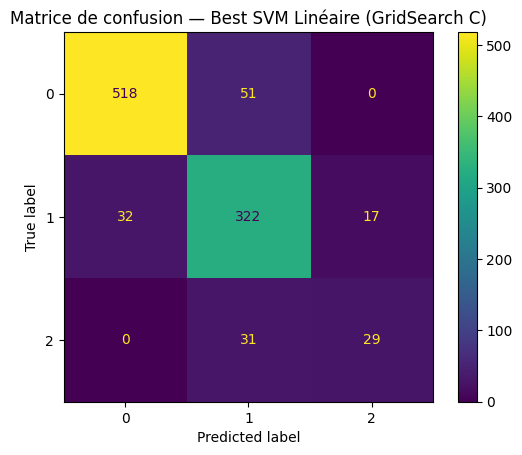

In [12]:
param_grid_linear = {
    "svc__C": [0.01, 0.1, 1, 10, 100]
}

grid_linear = GridSearchCV(
    estimator=Pipeline([("scaler", StandardScaler()), ("svc", SVC(kernel="linear"))]),
    param_grid=param_grid_linear,
    scoring="f1_macro",
    cv=5,
    n_jobs=-1
)

grid_linear.fit(X_train, y_train)

print("Meilleur C (linéaire):", grid_linear.best_params_)
print("Meilleur score CV (f1_macro):", grid_linear.best_score_)

best_linear = grid_linear.best_estimator_
res_best_linear = evaluate_model(best_linear, X_test, y_test, title="Best SVM Linéaire (GridSearch C)")


Meilleurs params (RBF): {'svc__C': 100, 'svc__gamma': 0.01}
Meilleur score CV (f1_macro): 0.7713786108383068
=== Best SVM RBF (GridSearch C+gamma) ===
Accuracy     : 0.8580
F1-macro     : 0.7346
F1-weighted  : 0.8553

Classification report (par classe):
              precision    recall  f1-score   support

           0       0.94      0.90      0.92       569
           1       0.78      0.87      0.82       371
           2       0.59      0.38      0.46        60

    accuracy                           0.86      1000
   macro avg       0.77      0.72      0.73      1000
weighted avg       0.86      0.86      0.86      1000



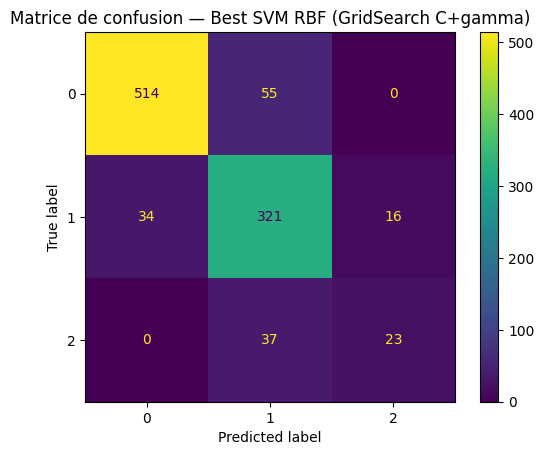

In [13]:
param_grid_rbf = {
    "svc__C": [0.1, 1, 10, 100],
    "svc__gamma": [0.001, 0.01, 0.1, 1, "scale"]
}

grid_rbf = GridSearchCV(
    estimator=Pipeline([("scaler", StandardScaler()), ("svc", SVC(kernel="rbf"))]),
    param_grid=param_grid_rbf,
    scoring="f1_macro",
    cv=5,
    n_jobs=-1
)

grid_rbf.fit(X_train, y_train)

print("Meilleurs params (RBF):", grid_rbf.best_params_)
print("Meilleur score CV (f1_macro):", grid_rbf.best_score_)

best_rbf = grid_rbf.best_estimator_
res_best_rbf = evaluate_model(best_rbf, X_test, y_test, title="Best SVM RBF (GridSearch C+gamma)")


In [14]:
final_model = best_rbf  # ou best_linear

y_pred = final_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

print("Matrice de confusion:\n", cm)

# Confusions les plus fréquentes 
cm_off = cm.copy()
np.fill_diagonal(cm_off, 0)

pairs = []
classes = np.unique(y_test)
for i, c_true in enumerate(classes):
    for j, c_pred in enumerate(classes):
        if i != j and cm_off[i, j] > 0:
            pairs.append((cm_off[i, j], c_true, c_pred))

pairs_sorted = sorted(pairs, reverse=True)[:5]
print("\nTop confusions (nb, vrai -> prédit):")
for n, t, p in pairs_sorted:
    print(f"{n} : {t} -> {p}")


Matrice de confusion:
 [[514  55   0]
 [ 34 321  16]
 [  0  37  23]]

Top confusions (nb, vrai -> prédit):
55 : 0 -> 1
37 : 2 -> 1
34 : 1 -> 0
16 : 1 -> 2
